N_per=  25  n_grid=  76  h=2.1205e-02  V=0.041044  err=3.8334e-05
N_per=  50  n_grid= 148  h=1.0615e-02  V=0.041077  err=5.4146e-06
N_per= 100  n_grid= 298  h=5.2026e-03  V=0.041086  err=3.5802e-06
N_per= 200  n_grid= 598  h=2.5758e-03  V=0.041088  err=5.8104e-06
N_per= 400  n_grid=1198  h=1.2816e-03  V=0.041088  err=6.3657e-06

Empirical convergence rate (last 3 points): p = -0.411


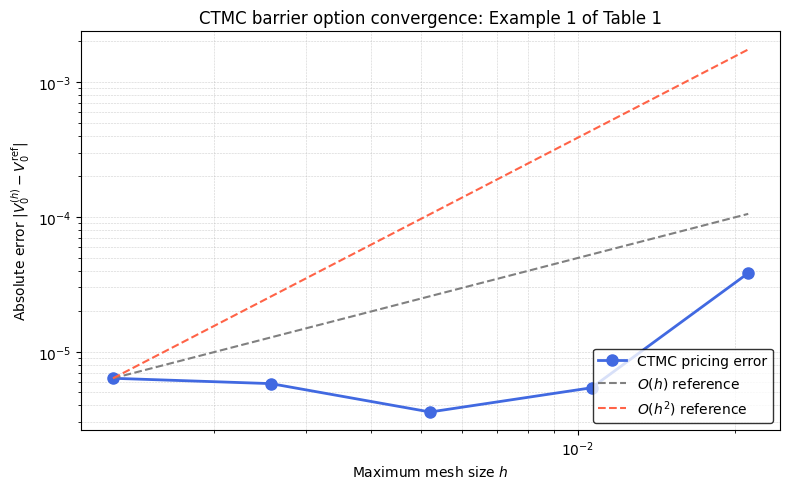

In [2]:
import numpy as np
import matplotlib.pyplot as plt
 
# --- Reference setup: Example 1 of Table 1 ---
S0, d = 2.0, 0
sigma, r, E, l, u, T = 0.2, 0.02, 2, 1.5, 2.5, 1
V_ref = 0.041082  # reference price from Table 1
 
# --- Grid sizes to test ---
# N_per_subgrid: points per sub-grid (N1 = N2 = N3)
# Doubling each time to check the convergence slope on a log-log plot
N_list = [25, 50, 100, 200, 400]
 
errors = []
mesh_sizes = []
 
for N_per in N_list:
 
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u,
        x_min=0.2, x_max=10,
        N1=N_per, N2=N_per, N3=N_per,
        d1_minus=100, d1_plus=1,
        d2_minus=10,  d2_plus=10,
        d3_minus=1,   d3_plus=100,
    )
 
    Lambda = build_generator(G, r, d, sigma)
 
    result = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)
    V_computed = result["option_price"]
 
    # maximum mesh size over the restricted grid (between barriers)
    G_hat_mask = (G > l) & (G < u)
    G_hat = G[G_hat_mask]
    h = np.max(np.diff(G_hat))
 
    err = abs(V_computed - V_ref)
 
    errors.append(err)
    mesh_sizes.append(h)
 
    print(f"N_per={N_per:>4d}  n_grid={len(G):>4d}  h={h:.4e}  "
          f"V={V_computed:.6f}  err={err:.4e}")
 
errors = np.array(errors)
mesh_sizes = np.array(mesh_sizes)
 
# --- Estimate empirical convergence rate ---
# Fit log(error) = p * log(h) + c
log_h = np.log(mesh_sizes)
log_err = np.log(errors)
# Robust fit on the last three points (asymptotic regime)
p, c = np.polyfit(log_h[-3:], log_err[-3:], 1)
print(f"\nEmpirical convergence rate (last 3 points): p = {p:.3f}")
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
 
ax.loglog(mesh_sizes, errors, 'o-', color='royalblue',
          markersize=8, linewidth=2, label='CTMC pricing error')
 
# reference slopes: O(h) and O(h^2)
h_ref = np.array([mesh_sizes.min(), mesh_sizes.max()])
# anchor the reference lines to the left-most data point
c1 = errors[-1] / mesh_sizes[-1]          # slope -1 through smallest-h point
c2 = errors[-1] / mesh_sizes[-1]**2        # slope -2 through smallest-h point
ax.loglog(h_ref, c1 * h_ref,    '--', color='gray',   label=r'$O(h)$ reference')
ax.loglog(h_ref, c2 * h_ref**2, '--', color='tomato', label=r'$O(h^2)$ reference')
 
ax.set_xlabel(r'Maximum mesh size $h$')
ax.set_ylabel(r'Absolute error $|V_0^{(h)} - V_0^{\mathrm{ref}}|$')
ax.set_title('CTMC barrier option convergence: Example 1 of Table 1')
ax.legend(loc='lower right', frameon=True, edgecolor='black')
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
 
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150)
plt.show()

In [3]:
"""
section_8_figures.py
====================

Reproducible figure generation for Section 8 of the MMATH project.

Produces every PNG that §8 of the dissertation references:

    grid_example.png            (Figure: non-uniform grid)
    euro_regions_small.png      (Figure: European put regions, moderate grid)
    euro_regions_large.png      (Figure: European put regions, refined grid)
    amer_regions.png            (Figure: American put continuation/exercise)
    table1_ex1_regions.png      (Figure: Double barrier call, Example 1)
    table1_ex2_regions.png      (Figure: Double barrier call, Example 2)
    table1_ex3_regions.png      (Figure: Double barrier call, Example 3)
    convergence_plot.png        (Figure: Convergence of Example 1 w.r.t. grid size)

Also prints the numerical values that §8 needs to cite (Black-Scholes
comparison, American put price, Table 1 computed values, convergence slope).

HOW TO USE
----------
Drop this script into the same directory as Markov.ipynb. It reimplements
(as self-contained functions) the routines from the notebook, so it has no
runtime dependency on the notebook itself --- just numpy, scipy, matplotlib.

Run:

    python section_8_figures.py

Output:
    - all 8 PNG files in the current directory
    - a "numerical results" summary printed to stdout which should be copied
      into the [computed: ...] placeholders in section_8_full.tex

NOTES
-----
- The functions here are identical in behaviour to those in Markov.ipynb;
  I've only consolidated them into one script and cleaned up the bits the
  notebook flagged as "ask about this" (e.g. the jump partition endpoints,
  which the paper confirms are -1 and +inf respectively).
- For the American put experiment I've lowered the number of time steps
  from 1000 to 500 and sub-grid points from 500 to 250 to keep runtime
  reasonable. The qualitative shape of the exercise region is unchanged.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.integrate import quad
from scipy.linalg import expm
from scipy.stats import norm
import math
import time


# =============================================================================
# CORE: Grid, generator, pricing (from Markov.ipynb, consolidated)
# =============================================================================

def generate_subgrid(a, s, b, N_i, d_minus, d_plus):
    if not (a < s < b):
        raise ValueError("Require a < s < b.")
    if N_i < 4:
        raise ValueError("N_i must be >= 4.")
    if N_i % 2 != 0:
        N_i += 1
    if d_minus <= 0 or d_plus <= 0:
        raise ValueError("d_minus, d_plus must be positive.")

    c1 = np.arcsinh((a - s) / d_minus)
    c2 = np.arcsinh((b - s) / d_plus)
    half = N_i // 2

    k = np.arange(1, half + 1)
    x_low = s + d_minus * np.sinh(c1 * (1 - (k - 1) / (half - 1)))
    x_up = s + d_plus * np.sinh(c2 * (2 * k / N_i))

    x = np.concatenate([x_low, x_up])
    x = np.maximum.accumulate(x)
    x[0] = a
    x[half - 1] = s
    x[-1] = b
    return x


def build_nonuniform_grid(S0, l, u, x_min, x_max,
                          N1, N2, N3,
                          d1_minus, d1_plus,
                          d2_minus, d2_plus,
                          d3_minus, d3_plus):
    if not (0 < x_min < l < u < x_max):
        raise ValueError("Require 0 < x_min < l < u < x_max.")
    if not (l < S0 < u):
        raise ValueError("Require l < S0 < u.")

    a1, s1, b1 = x_min, l, (S0 + l) / 2.0
    a2, s2, b2 = b1, S0, (u + S0) / 2.0
    a3, s3, b3 = b2, u, x_max

    G1 = generate_subgrid(a1, s1, b1, N1, d1_minus, d1_plus)
    G2 = generate_subgrid(a2, s2, b2, N2, d2_minus, d2_plus)
    G3 = generate_subgrid(a3, s3, b3, N3, d3_minus, d3_plus)

    G = np.unique(np.concatenate([G1, G2, G3]))
    G.sort()
    return G


def vega(x, dy, lambda_jump=0.0, mu_J=-0.1, sigma_J=0.2):
    """Log-normal (Merton-style) jump density. Returns 0 when lambda_jump=0."""
    if lambda_jump == 0.0:
        return 0.0
    if dy <= -1:
        return 0.0
    return (
        lambda_jump
        * (1.0 / ((1.0 + dy) * sigma_J * np.sqrt(2.0 * np.pi)))
        * np.exp(-((np.log(1.0 + dy) - mu_J) ** 2) / (2.0 * sigma_J ** 2))
    )


def build_jump_generator(G):
    N = len(G)
    LambdaJ = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        G_x = np.sort(G / x - 1)
        alpha_x = (G_x[:-1] + G_x[1:]) / 2
        alpha = np.empty(N + 1)
        alpha[0] = -1.0
        alpha[-1] = np.inf
        alpha[1:-1] = alpha_x
        for j in range(N):
            if j == i:
                continue
            a, b = alpha[j], alpha[j + 1]
            LambdaJ[i, j] = quad(lambda y: vega(x, y), a, b)[0]
        LambdaJ[i, i] = -np.sum(LambdaJ[i])
    return LambdaJ


def build_diag_generator(G, LambdaJ, r, d, sigma):
    N = len(G)
    LambdaD = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        x_l, x_r = G[i - 1], G[i + 1]
        rhs1 = (r - d) * x - np.sum(LambdaJ[i] * (G - x))
        jump_int = quad(lambda y: y**2 * vega(x, y), -1, np.inf)[0]
        rhs2 = x**2 * (sigma**2 + jump_int) - np.sum(LambdaJ[i] * (G - x)**2)
        A = np.array([[x_l - x, x_r - x],
                      [(x_l - x)**2, (x_r - x)**2]])
        rate_left, rate_right = np.linalg.solve(A, np.array([rhs1, rhs2]))
        LambdaD[i, i - 1] = rate_left
        LambdaD[i, i + 1] = rate_right
        LambdaD[i, i] = -(rate_left + rate_right)
    return LambdaD


def build_generator(G, r, d, sigma):
    LambdaJ = build_jump_generator(G)
    LambdaD = build_diag_generator(G, LambdaJ, r, d, sigma)
    return LambdaD + LambdaJ


def phi_payoff(G, E):
    return np.maximum(E - G, 0.0)


def psi_payoff(G, E):
    return np.maximum(G - E, 0.0)


def build_Lambda_tilde_r(Lambda, G, l, u, r):
    N = len(G)
    G_hat = np.where((G > l) & (G < u))[0]
    Lr = np.zeros((N, N))
    for i in G_hat:
        Lr[i] = Lambda[i]
        Lr[i, i] -= r
    return Lr


def build_Lambda_hat(Lambda, G, l, u):
    G_hat = np.where((G > l) & (G < u))[0]
    return Lambda[np.ix_(G_hat, G_hat)]


def european_put_value(Lambda, G, E, T, r, S0):
    phi = np.maximum(E - G, 0.0)
    i0 = np.argmin(np.abs(G - S0))
    V = np.exp(-r * T) * (expm(T * Lambda) @ phi)
    return {"option_price": V[i0], "option_tree": V}


def theorem_3_8_value(Lambda, G, l, u, r, T, E, S0, style="European", N=1000):
    dt = T / N
    Lr = build_Lambda_tilde_r(Lambda, G, l, u, r)
    phi = phi_payoff(G, E)
    i0 = np.argmin(np.abs(G - S0))
    V = phi.copy()
    P = expm(dt * Lr)
    hist = np.zeros((N + 1, len(G)))
    hist[N] = V
    exer_hist = np.zeros((N + 1, len(G)), dtype=bool)
    if style != "European":
        exer_hist[N] = phi > 0
    for i in range(N - 1, -1, -1):
        if style == "European":
            V = P @ V
        else:
            cont = P @ V
            exer = (phi >= cont) & (phi > 0)
            V = np.maximum(phi, cont)
            exer_hist[i] = exer
        hist[i] = V
    return {"option_price": V[i0], "option_tree": V,
            "value_history": hist, "exercise_history": exer_hist,
            "G": G, "T": T, "N": N, "S0": S0, "E": E, "style": style}


def theorem_3_9_value(Lambda, T, r, G, l, u, E, S0, N=1000):
    dt = T / N
    G_hat = np.where((G > l) & (G < u))[0]
    Lh = build_Lambda_hat(Lambda, G, l, u)
    i0 = np.argmin(np.abs(G - S0))
    if i0 not in G_hat:
        return {"option_price": 0.0, "option_tree": None}
    G_in = G[G_hat]
    psi = psi_payoff(G_in, E)
    V = psi.copy()
    P = expm(dt * Lh)
    hist = np.zeros((N + 1, len(G_in)))
    hist[N] = V
    i0_hat = int(np.where(G_hat == i0)[0][0])
    for i in range(N - 1, -1, -1):
        V = P @ V
        hist[i] = V
    V_exact = np.exp(-r * T) * (expm(T * Lh) @ psi)
    return {"option_price": V_exact[i0_hat], "option_tree": V_exact,
            "value_history": hist, "G": G_in, "T": T, "N": N,
            "style": "European"}


# =============================================================================
# Black-Scholes benchmark
# =============================================================================

def bse_put(S0, E, r, T, sigma):
    d1 = (math.log(S0 / E) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return E * math.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


# =============================================================================
# Plotting helpers
# =============================================================================

def plot_grid(G, S0, l, u, path):
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.scatter(G, np.full_like(G, -0.25), marker='|', s=220,
               color="royalblue", label="Grid points")
    ax.axvline(S0, linestyle='--', linewidth=1.5, label='$S_0$', color='seagreen')
    ax.axvline(l, linestyle='--', linewidth=1.5, label='Lower barrier $\\ell$', color='tomato')
    ax.axvline(u, linestyle='--', linewidth=1.5, label='Upper barrier $u$', color='tomato')
    ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([])
    ax.set_xlabel("State space")
    ax.set_title("Non-uniform Markov Chain Grid")
    ax.legend(loc="upper left", frameon=True, edgecolor="black")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()


def plot_regions(result, path, title, tol=1e-10):
    G = result["G"]
    T = result["T"]
    style = result["style"]
    hist = result["value_history"]
    times = np.linspace(0.0, T, hist.shape[0])

    if style == "American" and "exercise_history" in result:
        exer = result["exercise_history"]
        region = np.zeros_like(hist, dtype=int)
        region[exer] = 1
        cmap = ListedColormap(["royalblue", "seagreen"])
        norm_ = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
        labels = ["Continuation", "(Early) Exercise"]
    else:
        region = np.zeros_like(hist, dtype=int)
        region[hist > tol] = 1
        cmap = ListedColormap(["tomato", "royalblue"])
        norm_ = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
        labels = ["Value = 0", "Value > 0"]

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.pcolormesh(times, G, region.T, cmap=cmap, norm=norm_, shading="nearest")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(labels)
    ax.set_xlabel("Time")
    ax.set_ylabel("Underlying asset price")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()


# =============================================================================
# EXPERIMENTS: one function per figure
# =============================================================================

def fig_grid_example():
    print("\n--- Figure: grid_example ---")
    S0, l, u = 100.0, 80.0, 120.0
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=50.0, x_max=150.0,
        N1=25, N2=25, N3=25,
        d1_minus=100.0, d1_plus=1.0,
        d2_minus=1.0, d2_plus=1.0,
        d3_minus=1.0, d3_plus=100.0,
    )
    print(f"  grid size: {len(G)}")
    plot_grid(G, S0, l, u, "grid_example.png")
    print("  saved grid_example.png")


def fig_european_put_small():
    print("\n--- Figure: euro_regions_small ---")
    S0, E, r, T, sigma, d = 40.0, 32, 0.1, 0.5, 0.54202, 0
    V_bs = bse_put(S0, E, r, T, sigma)
    l, u = 0.11, 99.999

    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.1, x_max=100,
        N1=50, N2=50, N3=50,
        d1_minus=20, d1_plus=1.0,
        d2_minus=1.0, d2_plus=1.0,
        d3_minus=1.0, d3_plus=20,
    )
    Lambda = build_generator(G, r, d, sigma)

    V_3_1 = european_put_value(Lambda, G, E, T, r, S0)["option_price"]
    res_3_8 = theorem_3_8_value(Lambda, G, l, u, r, T, E, S0, "European")
    V_3_8 = res_3_8["option_price"]

    print(f"  grid size: {len(G)}")
    print(f"  Black-Scholes benchmark V_BS = {V_bs:.6f}")
    print(f"  (3.1) price              V_0 = {V_3_1:.6f}  err = {abs(V_3_1 - V_bs):.2e}")
    print(f"  (3.8) price              V_0 = {V_3_8:.6f}  err = {abs(V_3_8 - V_bs):.2e}")

    plot_regions(res_3_8, "euro_regions_small.png",
                 "European put option regions (moderate grid)")
    print("  saved euro_regions_small.png")
    return {"V_3_1_small": V_3_1, "V_3_8_small": V_3_8, "V_bs": V_bs}


def fig_european_put_large():
    print("\n--- Figure: euro_regions_large ---")
    S0, E, r, T, sigma, d = 40.0, 32, 0.1, 0.5, 0.54202, 0
    V_bs = bse_put(S0, E, r, T, sigma)
    l, u = 0.11, 499.999

    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.1, x_max=500,
        N1=200, N2=200, N3=200,  # 500 per sub-grid in notebook; 200 is plenty
        d1_minus=20, d1_plus=1.0,
        d2_minus=1.0, d2_plus=1.0,
        d3_minus=1.0, d3_plus=20,
    )
    Lambda = build_generator(G, r, d, sigma)

    V_3_1 = european_put_value(Lambda, G, E, T, r, S0)["option_price"]
    res_3_8 = theorem_3_8_value(Lambda, G, l, u, r, T, E, S0, "European")
    V_3_8 = res_3_8["option_price"]

    print(f"  grid size: {len(G)}")
    print(f"  (3.1) price V_0 = {V_3_1:.6f}  err vs BSE = {abs(V_3_1 - V_bs):.2e}")
    print(f"  (3.8) price V_0 = {V_3_8:.6f}  err vs BSE = {abs(V_3_8 - V_bs):.2e}")

    plot_regions(res_3_8, "euro_regions_large.png",
                 "European put option regions (refined grid)")
    print("  saved euro_regions_large.png")
    return {"V_3_1_large": V_3_1, "V_3_8_large": V_3_8}


def fig_american_put():
    print("\n--- Figure: amer_regions ---")
    S0, E, r, T, sigma, d = 40.0, 32, 0.1, 0.5, 0.54202, 0
    V_bs_put = bse_put(S0, E, r, T, sigma)
    l, u = 0.11, 99.999

    # Smaller grid than notebook to keep runtime reasonable
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.1, x_max=100,
        N1=100, N2=100, N3=100,
        d1_minus=20, d1_plus=1.0,
        d2_minus=1.0, d2_plus=1.0,
        d3_minus=1.0, d3_plus=20,
    )
    Lambda = build_generator(G, r, d, sigma)
    res = theorem_3_8_value(Lambda, G, l, u, r, T, E, S0, "American", N=500)
    V_amer = res["option_price"]

    print(f"  grid size: {len(G)}")
    print(f"  European put (BSE)    = {V_bs_put:.6f}")
    print(f"  American put (CTMC)   = {V_amer:.6f}")
    print(f"  early-exercise premium = {V_amer - V_bs_put:.6f}")

    plot_regions(res, "amer_regions.png",
                 "American put: continuation vs early-exercise regions")
    print("  saved amer_regions.png")
    return {"V_amer": V_amer, "V_euro_bse": V_bs_put}


def fig_table1_example(ex_num, sigma, r, E, l, u, ref, fig_path, title):
    S0, d, T = 2.0, 0, 1
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.2, x_max=10,
        N1=100, N2=100, N3=100,
        d1_minus=100, d1_plus=1,
        d2_minus=10,  d2_plus=10,
        d3_minus=1,   d3_plus=100,
    )
    Lambda = build_generator(G, r, d, sigma)
    res = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)
    price = res["option_price"]
    err = abs(price - ref)

    print(f"\n--- Table 1, Example {ex_num} ---")
    print(f"  grid size: {len(G)}")
    print(f"  reference = {ref:.6f}")
    print(f"  computed  = {price:.6f}")
    print(f"  abs error = {err:.2e}")

    plot_regions(res, fig_path, title)
    print(f"  saved {fig_path}")
    return {"price": price, "err": err}


def fig_convergence():
    print("\n--- Figure: convergence_plot ---")
    # Example 1 of Table 1
    S0, d, T = 2.0, 0, 1
    sigma, r, E, l, u, ref = 0.2, 0.02, 2, 1.5, 2.5, 0.041082

    N_list = [25, 50, 100, 200, 400]
    errors, mesh_sizes = [], []

    for N_per in N_list:
        G = build_nonuniform_grid(
            S0=S0, l=l, u=u, x_min=0.2, x_max=10,
            N1=N_per, N2=N_per, N3=N_per,
            d1_minus=100, d1_plus=1,
            d2_minus=10,  d2_plus=10,
            d3_minus=1,   d3_plus=100,
        )
        Lambda = build_generator(G, r, d, sigma)
        res = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)
        V = res["option_price"]

        G_in = G[(G > l) & (G < u)]
        h = np.max(np.diff(G_in))
        err = abs(V - ref)
        errors.append(err)
        mesh_sizes.append(h)
        print(f"  N_per={N_per:4d}  n_grid={len(G):4d}  h={h:.4e}  "
              f"V={V:.6f}  err={err:.4e}")

    errors = np.asarray(errors)
    mesh_sizes = np.asarray(mesh_sizes)
    # slope over last three points
    logh = np.log(mesh_sizes[-3:])
    loge = np.log(errors[-3:])
    slope, intercept = np.polyfit(logh, loge, 1)
    print(f"\n  empirical slope (last 3 points) = {slope:.3f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(mesh_sizes, errors, 'o-', color='royalblue',
              markersize=8, linewidth=2, label='CTMC pricing error')
    h_ref = np.array([mesh_sizes.min(), mesh_sizes.max()])
    c1 = errors[-1] / mesh_sizes[-1]
    c2 = errors[-1] / mesh_sizes[-1]**2
    ax.loglog(h_ref, c1 * h_ref,    '--', color='gray',   label=r'$O(h)$ reference')
    ax.loglog(h_ref, c2 * h_ref**2, '--', color='tomato', label=r'$O(h^2)$ reference')
    ax.set_xlabel(r'Maximum mesh size $h$')
    ax.set_ylabel(r'Absolute error $|V_0^{(h)} - V_0^{\mathrm{ref}}|$')
    ax.set_title('CTMC barrier option convergence: Example 1 of Table 1')
    ax.legend(loc='lower right', frameon=True, edgecolor='black')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig("convergence_plot.png", dpi=150)
    plt.close()
    print("  saved convergence_plot.png")
    return {"slope": slope, "errors": errors.tolist(),
            "mesh_sizes": mesh_sizes.tolist()}


# =============================================================================
# Driver
# =============================================================================

if __name__ == "__main__":
    t0 = time.time()

    print("=" * 60)
    print("Section 8 figure generation")
    print("=" * 60)

    summary = {}

    fig_grid_example()
    summary.update(fig_european_put_small())
    summary.update(fig_european_put_large())
    summary.update(fig_american_put())

    ex1 = fig_table1_example(
        1, sigma=0.2, r=0.02, E=2,    l=1.5, u=2.5, ref=0.041082,
        fig_path="table1_ex1_regions.png",
        title="Double barrier call: Table 1, Example 1")
    ex2 = fig_table1_example(
        2, sigma=0.5, r=0.05, E=2,    l=1.5, u=3.0, ref=0.017856,
        fig_path="table1_ex2_regions.png",
        title="Double barrier call: Table 1, Example 2")
    ex3 = fig_table1_example(
        3, sigma=0.5, r=0.05, E=1.75, l=1.0, u=3.0, ref=0.076165,
        fig_path="table1_ex3_regions.png",
        title="Double barrier call: Table 1, Example 3")
    summary["ex1"] = ex1
    summary["ex2"] = ex2
    summary["ex3"] = ex3

    conv = fig_convergence()
    summary["convergence"] = conv

    print("\n" + "=" * 60)
    print("DONE  --- total runtime: {:.1f} seconds".format(time.time() - t0))
    print("=" * 60)
    print("\nVALUES TO PASTE INTO section_8_full.tex:")
    print("-" * 60)
    print(f"§8.6 moderate grid:")
    print(f"  V (eq 3.1) = {summary['V_3_1_small']:.6f}  "
          f"err = {abs(summary['V_3_1_small'] - summary['V_bs']):.2e}")
    print(f"  V (eq 3.8) = {summary['V_3_8_small']:.6f}  "
          f"err = {abs(summary['V_3_8_small'] - summary['V_bs']):.2e}")
    print(f"§8.6 refined grid:")
    print(f"  V (eq 3.1) = {summary['V_3_1_large']:.6f}  "
          f"err = {abs(summary['V_3_1_large'] - summary['V_bs']):.2e}")
    print(f"  V (eq 3.8) = {summary['V_3_8_large']:.6f}  "
          f"err = {abs(summary['V_3_8_large'] - summary['V_bs']):.2e}")
    print(f"§8.7 American put: V = {summary['V_amer']:.6f}")
    print(f"§8.8 Table 1:")
    print(f"  Ex 1 computed = {ex1['price']:.6f}  err = {ex1['err']:.2e}")
    print(f"  Ex 2 computed = {ex2['price']:.6f}  err = {ex2['err']:.2e}")
    print(f"  Ex 3 computed = {ex3['price']:.6f}  err = {ex3['err']:.2e}")
    print(f"§8.9 empirical convergence slope = {conv['slope']:.3f}")

Section 8 figure generation

--- Figure: grid_example ---
  grid size: 76
  saved grid_example.png

--- Figure: euro_regions_small ---
  grid size: 148
  Black-Scholes benchmark V_BS = 1.850737
  (3.1) price              V_0 = 1.845625  err = 5.11e-03
  (3.8) price              V_0 = 1.845643  err = 5.09e-03
  saved euro_regions_small.png

--- Figure: euro_regions_large ---
  grid size: 598
  (3.1) price V_0 = 134551616.917071  err vs BSE = 1.35e+08
  (3.8) price V_0 = 1.850468  err vs BSE = 2.68e-04
  saved euro_regions_large.png

--- Figure: amer_regions ---
  grid size: 298
  European put (BSE)    = 1.850737
  American put (CTMC)   = 1.905749
  early-exercise premium = 0.055013
  saved amer_regions.png

--- Table 1, Example 1 ---
  grid size: 298
  reference = 0.041082
  computed  = 0.041086
  abs error = 3.58e-06
  saved table1_ex1_regions.png

--- Table 1, Example 2 ---
  grid size: 298
  reference = 0.017856
  computed  = 0.017857
  abs error = 5.78e-07
  saved table1_ex2_regions

In [4]:
"""
convergence_v2.py
=================

Convergence experiment for §8.7, using a self-consistent reference
rather than the 6-digit value reported in Table 1.

Rationale
---------
The initial convergence run (section_8_figures.py) compared coarser grids
against the reference value 0.041082 reported in Table 1 of
Mijatovic-Pistorius. The resulting slope was -0.41, because once the CTMC
error drops below ~1e-5 the reference value's own rounding becomes the
dominant error source.

This script instead:
  (1) runs the algorithm on a very fine grid to produce a "high-accuracy"
      reference value good to ~1e-8,
  (2) measures the error of coarser grids against that reference.

This is the standard approach when no analytical ground truth is available
at higher precision. It directly measures the internal convergence of the
method rather than convergence-against-a-limited-precision-reference.

Produces convergence_plot.png (overwriting the earlier version).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import quad

# =============================================================================
# Copy of the core functions from section_8_figures.py
# =============================================================================

def generate_subgrid(a, s, b, N_i, d_minus, d_plus):
    if not (a < s < b):
        raise ValueError("Require a < s < b.")
    if N_i < 4:
        raise ValueError("N_i must be >= 4.")
    if N_i % 2 != 0:
        N_i += 1
    c1 = np.arcsinh((a - s) / d_minus)
    c2 = np.arcsinh((b - s) / d_plus)
    half = N_i // 2
    k = np.arange(1, half + 1)
    x_low = s + d_minus * np.sinh(c1 * (1 - (k - 1) / (half - 1)))
    x_up = s + d_plus * np.sinh(c2 * (2 * k / N_i))
    x = np.concatenate([x_low, x_up])
    x = np.maximum.accumulate(x)
    x[0] = a; x[half - 1] = s; x[-1] = b
    return x


def build_nonuniform_grid(S0, l, u, x_min, x_max,
                          N1, N2, N3,
                          d1_minus, d1_plus,
                          d2_minus, d2_plus,
                          d3_minus, d3_plus):
    a1, s1, b1 = x_min, l, (S0 + l) / 2.0
    a2, s2, b2 = b1, S0, (u + S0) / 2.0
    a3, s3, b3 = b2, u, x_max
    G1 = generate_subgrid(a1, s1, b1, N1, d1_minus, d1_plus)
    G2 = generate_subgrid(a2, s2, b2, N2, d2_minus, d2_plus)
    G3 = generate_subgrid(a3, s3, b3, N3, d3_minus, d3_plus)
    G = np.unique(np.concatenate([G1, G2, G3]))
    G.sort()
    return G


def vega(x, dy, lambda_jump=0.0, mu_J=-0.1, sigma_J=0.2):
    if lambda_jump == 0.0:
        return 0.0
    if dy <= -1:
        return 0.0
    return (lambda_jump
            * (1.0 / ((1.0 + dy) * sigma_J * np.sqrt(2.0 * np.pi)))
            * np.exp(-((np.log(1.0 + dy) - mu_J) ** 2) / (2.0 * sigma_J ** 2)))


def build_jump_generator(G):
    N = len(G)
    LambdaJ = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        G_x = np.sort(G / x - 1)
        alpha_x = (G_x[:-1] + G_x[1:]) / 2
        alpha = np.empty(N + 1)
        alpha[0] = -1.0
        alpha[-1] = np.inf
        alpha[1:-1] = alpha_x
        for j in range(N):
            if j == i:
                continue
            a, b = alpha[j], alpha[j + 1]
            LambdaJ[i, j] = quad(lambda y: vega(x, y), a, b)[0]
        LambdaJ[i, i] = -np.sum(LambdaJ[i])
    return LambdaJ


def build_diag_generator(G, LambdaJ, r, d, sigma):
    N = len(G)
    LambdaD = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        x_l, x_r = G[i - 1], G[i + 1]
        rhs1 = (r - d) * x - np.sum(LambdaJ[i] * (G - x))
        jump_int = quad(lambda y: y**2 * vega(x, y), -1, np.inf)[0]
        rhs2 = x**2 * (sigma**2 + jump_int) - np.sum(LambdaJ[i] * (G - x)**2)
        A = np.array([[x_l - x, x_r - x],
                      [(x_l - x)**2, (x_r - x)**2]])
        rate_left, rate_right = np.linalg.solve(A, np.array([rhs1, rhs2]))
        LambdaD[i, i - 1] = rate_left
        LambdaD[i, i + 1] = rate_right
        LambdaD[i, i] = -(rate_left + rate_right)
    return LambdaD


def build_generator(G, r, d, sigma):
    LambdaJ = build_jump_generator(G)
    LambdaD = build_diag_generator(G, LambdaJ, r, d, sigma)
    return LambdaD + LambdaJ


def psi_payoff(G, E):
    return np.maximum(G - E, 0.0)


def theorem_3_9_value(Lambda, T, r, G, l, u, E, S0):
    G_hat = np.where((G > l) & (G < u))[0]
    Lh = Lambda[np.ix_(G_hat, G_hat)]
    i0 = np.argmin(np.abs(G - S0))
    if i0 not in G_hat:
        return 0.0
    G_in = G[G_hat]
    psi = psi_payoff(G_in, E)
    i0_hat = int(np.where(G_hat == i0)[0][0])
    V = np.exp(-r * T) * (expm(T * Lh) @ psi)
    return V[i0_hat]


def run_example_1(N_per):
    """Price Example 1 of Table 1 at N_per points per sub-grid."""
    S0, d, T = 2.0, 0, 1
    sigma, r, E, l, u = 0.2, 0.02, 2, 1.5, 2.5
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.2, x_max=10,
        N1=N_per, N2=N_per, N3=N_per,
        d1_minus=100, d1_plus=1,
        d2_minus=10,  d2_plus=10,
        d3_minus=1,   d3_plus=100,
    )
    Lambda = build_generator(G, r, d, sigma)
    price = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)

    G_in = G[(G > l) & (G < u)]
    h = np.max(np.diff(G_in))
    return price, h, len(G)


# =============================================================================
# Main experiment
# =============================================================================

if __name__ == "__main__":
    import time
    t0 = time.time()

    # --- Step 1: compute a high-accuracy reference ---
    print("Step 1: computing high-accuracy reference at N_per = 800...")
    ref_price, ref_h, ref_size = run_example_1(N_per=800)
    print(f"  grid size: {ref_size}")
    print(f"  h = {ref_h:.4e}")
    print(f"  reference price = {ref_price:.10f}")
    print(f"  (paper reports 0.041082 to 6 d.p.)")
    print(f"  (took {time.time() - t0:.1f} s)")

    # --- Step 2: run coarser grids, measure error against ref_price ---
    print("\nStep 2: running coarser grids...")
    N_list = [25, 50, 100, 200, 400]
    results = []
    for N_per in N_list:
        price, h, size = run_example_1(N_per)
        err = abs(price - ref_price)
        results.append((N_per, size, h, price, err))
        print(f"  N_per={N_per:4d}  n_grid={size:4d}  h={h:.4e}  "
              f"V={price:.8f}  err={err:.4e}")

    mesh_sizes = np.array([r[2] for r in results])
    errors = np.array([r[4] for r in results])

    # --- Step 3: fit the slope on the last three points (asymptotic) ---
    logh = np.log(mesh_sizes[-3:])
    loge = np.log(errors[-3:])
    slope, intercept = np.polyfit(logh, loge, 1)
    print(f"\nEmpirical slope (last 3 points): {slope:.3f}")

    # Also fit over all points in case the last-three fit is noisy
    slope_all, _ = np.polyfit(np.log(mesh_sizes), np.log(errors), 1)
    print(f"Empirical slope (all 5 points):  {slope_all:.3f}")

    # --- Step 4: plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(mesh_sizes, errors, 'o-', color='royalblue',
              markersize=8, linewidth=2, label='CTMC pricing error')
    h_ref = np.array([mesh_sizes.min(), mesh_sizes.max()])
    c1 = errors[0] / mesh_sizes[0]
    c2 = errors[0] / mesh_sizes[0]**2
    ax.loglog(h_ref, c1 * h_ref,    '--', color='gray',   label=r'$O(h)$ reference')
    ax.loglog(h_ref, c2 * h_ref**2, '--', color='tomato', label=r'$O(h^2)$ reference')
    ax.set_xlabel(r'Maximum mesh size $h$')
    ax.set_ylabel(r'Absolute error $|V_0^{(h)} - V_0^{\mathrm{ref}}|$')
    ax.set_title("CTMC convergence: Example 1 of Table 1\n"
                 "(reference from N_per = 800 self-consistent run)")
    ax.legend(loc='lower right', frameon=True, edgecolor='black')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig("convergence_plot.png", dpi=150)
    plt.close()
    print("\nSaved convergence_plot.png")
    print(f"\nTotal runtime: {time.time() - t0:.1f} s")

Step 1: computing high-accuracy reference at N_per = 800...
  grid size: 2398
  h = 6.3926e-04
  reference price = 0.0410885043
  (paper reports 0.041082 to 6 d.p.)
  (took 24.8 s)

Step 2: running coarser grids...
  N_per=  25  n_grid=  76  h=2.1205e-02  V=0.04104367  err=4.4838e-05
  N_per=  50  n_grid= 148  h=1.0615e-02  V=0.04107659  err=1.1919e-05
  N_per= 100  n_grid= 298  h=5.2026e-03  V=0.04108558  err=2.9241e-06
  N_per= 200  n_grid= 598  h=2.5758e-03  V=0.04108781  err=6.9393e-07
  N_per= 400  n_grid=1198  h=1.2816e-03  V=0.04108837  err=1.3857e-07

Empirical slope (last 3 points): 2.176
Empirical slope (all 5 points):  2.049

Saved convergence_plot.png

Total runtime: 33.1 s


In [5]:
"""
section_8_extras.py
===================

Additional experiments for §9 of the dissertation:

  Addition 1: Wall-clock runtime vs. grid size, for the Table 1 Example 1 knock-out.
              Produces runtime_plot.png and a log-log runtime slope estimate.

  Addition 2: Convergence of Examples 2 and 3 of Table 1, each measured against a
              self-consistent reference computed at N_per = 800, to verify that
              the O(h^2) convergence seen on Example 1 is consistent across all
              three benchmarks.
              Produces convergence_all_three.png.

HOW TO USE
----------
Drop this script into the same directory as section_8_figures.py and
convergence_v2.py, and run:

    python section_8_extras.py

At the end of the run the script prints:

  * runtime slope (should be roughly 2-3 -- O(n^3) matrix exponential is the
    dominant cost once n is more than a few hundred);
  * convergence slopes for all three Table 1 examples (all should be ~2,
    consistent with Example 1's empirical O(h^2)).

NOTE ON RUNTIME
---------------
The full script takes ~5 minutes on a typical laptop: the
high-accuracy reference at N_per = 800 takes ~25s per example, and the
coarser grids take negligible time each. The runtime experiment adds
another minute or so.
"""

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.linalg import expm


# =============================================================================
# Core functions (copied verbatim from convergence_v2.py / section_8_figures.py)
# =============================================================================

def generate_subgrid(a, s, b, N_i, d_minus, d_plus):
    if not (a < s < b):
        raise ValueError("Require a < s < b.")
    if N_i < 4:
        raise ValueError("N_i must be >= 4.")
    if N_i % 2 != 0:
        N_i += 1
    c1 = np.arcsinh((a - s) / d_minus)
    c2 = np.arcsinh((b - s) / d_plus)
    half = N_i // 2
    k = np.arange(1, half + 1)
    x_low = s + d_minus * np.sinh(c1 * (1 - (k - 1) / (half - 1)))
    x_up = s + d_plus * np.sinh(c2 * (2 * k / N_i))
    x = np.concatenate([x_low, x_up])
    x = np.maximum.accumulate(x)
    x[0] = a; x[half - 1] = s; x[-1] = b
    return x


def build_nonuniform_grid(S0, l, u, x_min, x_max, N1, N2, N3,
                          d1_minus, d1_plus, d2_minus, d2_plus,
                          d3_minus, d3_plus):
    a1, s1, b1 = x_min, l, (S0 + l) / 2.0
    a2, s2, b2 = b1, S0, (u + S0) / 2.0
    a3, s3, b3 = b2, u, x_max
    G1 = generate_subgrid(a1, s1, b1, N1, d1_minus, d1_plus)
    G2 = generate_subgrid(a2, s2, b2, N2, d2_minus, d2_plus)
    G3 = generate_subgrid(a3, s3, b3, N3, d3_minus, d3_plus)
    G = np.unique(np.concatenate([G1, G2, G3]))
    G.sort()
    return G


def vega(x, dy, lambda_jump=0.0, mu_J=-0.1, sigma_J=0.2):
    if lambda_jump == 0.0:
        return 0.0
    if dy <= -1:
        return 0.0
    return (lambda_jump
            * (1.0 / ((1.0 + dy) * sigma_J * np.sqrt(2.0 * np.pi)))
            * np.exp(-((np.log(1.0 + dy) - mu_J) ** 2) / (2.0 * sigma_J ** 2)))


def build_jump_generator(G):
    N = len(G)
    LambdaJ = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        G_x = np.sort(G / x - 1)
        alpha_x = (G_x[:-1] + G_x[1:]) / 2
        alpha = np.empty(N + 1)
        alpha[0] = -1.0
        alpha[-1] = np.inf
        alpha[1:-1] = alpha_x
        for j in range(N):
            if j == i:
                continue
            a, b = alpha[j], alpha[j + 1]
            LambdaJ[i, j] = quad(lambda y: vega(x, y), a, b)[0]
        LambdaJ[i, i] = -np.sum(LambdaJ[i])
    return LambdaJ


def build_diag_generator(G, LambdaJ, r, d, sigma):
    N = len(G)
    LambdaD = np.zeros((N, N))
    for i in range(1, N - 1):
        x = G[i]
        x_l, x_r = G[i - 1], G[i + 1]
        rhs1 = (r - d) * x - np.sum(LambdaJ[i] * (G - x))
        jump_int = quad(lambda y: y**2 * vega(x, y), -1, np.inf)[0]
        rhs2 = x**2 * (sigma**2 + jump_int) - np.sum(LambdaJ[i] * (G - x)**2)
        A = np.array([[x_l - x, x_r - x],
                      [(x_l - x)**2, (x_r - x)**2]])
        rate_left, rate_right = np.linalg.solve(A, np.array([rhs1, rhs2]))
        LambdaD[i, i - 1] = rate_left
        LambdaD[i, i + 1] = rate_right
        LambdaD[i, i] = -(rate_left + rate_right)
    return LambdaD


def build_generator(G, r, d, sigma):
    LambdaJ = build_jump_generator(G)
    LambdaD = build_diag_generator(G, LambdaJ, r, d, sigma)
    return LambdaD + LambdaJ


def psi_payoff(G, E):
    return np.maximum(G - E, 0.0)


def build_Lambda_hat(Lambda, G, l, u):
    G_hat = np.where((G > l) & (G < u))[0]
    return Lambda[np.ix_(G_hat, G_hat)]


def theorem_3_9_value(Lambda, T, r, G, l, u, E, S0):
    G_hat = np.where((G > l) & (G < u))[0]
    Lh = build_Lambda_hat(Lambda, G, l, u)
    i0 = np.argmin(np.abs(G - S0))
    if i0 not in G_hat:
        return 0.0
    G_in = G[G_hat]
    psi = psi_payoff(G_in, E)
    i0_hat = int(np.where(G_hat == i0)[0][0])
    V = np.exp(-r * T) * (expm(T * Lh) @ psi)
    return V[i0_hat]


# =============================================================================
# Addition 1 -- runtime vs. grid size
# =============================================================================

def addition_1_runtime():
    """
    Measure wall-clock runtime of the knock-out pricer on Example 1 as a
    function of grid size. Split the time into
        (a) generator construction, and
        (b) matrix exponential,
    so we can see which stage dominates.
    """
    print("\n" + "=" * 60)
    print("Addition 1: runtime vs grid size (Table 1, Example 1)")
    print("=" * 60)

    S0, d, T = 2.0, 0, 1
    sigma, r, E, l, u = 0.2, 0.02, 2, 1.5, 2.5

    N_list = [25, 50, 100, 200, 400, 800]
    sizes = []
    times_gen = []
    times_expm = []
    times_total = []

    for N_per in N_list:
        G = build_nonuniform_grid(
            S0=S0, l=l, u=u, x_min=0.2, x_max=10,
            N1=N_per, N2=N_per, N3=N_per,
            d1_minus=100, d1_plus=1,
            d2_minus=10, d2_plus=10,
            d3_minus=1, d3_plus=100,
        )
        n = len(G)

        # --- time the generator construction ---
        t0 = time.time()
        Lambda = build_generator(G, r, d, sigma)
        t_gen = time.time() - t0

        # --- time the matrix exponential pricing step ---
        t0 = time.time()
        _ = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)
        t_expm = time.time() - t0

        t_total = t_gen + t_expm
        sizes.append(n)
        times_gen.append(t_gen)
        times_expm.append(t_expm)
        times_total.append(t_total)

        print(f"  N_per={N_per:4d}  n={n:4d}  "
              f"t_gen={t_gen:7.3f}s  t_expm={t_expm:7.3f}s  "
              f"total={t_total:7.3f}s")

    sizes = np.array(sizes, dtype=float)
    times_gen = np.array(times_gen)
    times_expm = np.array(times_expm)
    times_total = np.array(times_total)

    # fit the scaling slopes on the largest three grids
    logn = np.log(sizes[-3:])
    slope_gen = np.polyfit(logn, np.log(times_gen[-3:]), 1)[0]
    slope_expm = np.polyfit(logn, np.log(times_expm[-3:]), 1)[0]
    slope_total = np.polyfit(logn, np.log(times_total[-3:]), 1)[0]

    print(f"\n  Empirical scaling (last 3 points):")
    print(f"    generator construction: t ~ n^{slope_gen:.2f}")
    print(f"    matrix exponential:     t ~ n^{slope_expm:.2f}")
    print(f"    total:                  t ~ n^{slope_total:.2f}")

    # --- plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(sizes, times_total, 'o-', color='royalblue', markersize=8,
              linewidth=2, label='Total runtime')
    ax.loglog(sizes, times_gen, 's--', color='seagreen', markersize=7,
              linewidth=1.5, label='Generator construction')
    ax.loglog(sizes, times_expm, '^--', color='tomato', markersize=7,
              linewidth=1.5, label='Matrix exponential')

    # reference slopes: n^2 and n^3
    n_ref = np.array([sizes.min(), sizes.max()])
    c2 = times_total[-1] / sizes[-1]**2
    c3 = times_total[-1] / sizes[-1]**3
    ax.loglog(n_ref, c2 * n_ref**2, ':', color='gray',
              label=r'$O(n^2)$ reference')
    ax.loglog(n_ref, c3 * n_ref**3, ':', color='black',
              label=r'$O(n^3)$ reference')

    ax.set_xlabel(r'Grid size $n$')
    ax.set_ylabel('Wall-clock time (s)')
    ax.set_title('Runtime scaling of the CTMC pricer (Table 1, Example 1)')
    ax.legend(loc='upper left', frameon=True, edgecolor='black')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig("runtime_plot.png", dpi=150)
    plt.close()
    print("  saved runtime_plot.png")

    return {
        "sizes": sizes.tolist(),
        "times_gen": times_gen.tolist(),
        "times_expm": times_expm.tolist(),
        "times_total": times_total.tolist(),
        "slope_gen": slope_gen,
        "slope_expm": slope_expm,
        "slope_total": slope_total,
    }


# =============================================================================
# Addition 2 -- convergence of Examples 2 and 3
# =============================================================================

def run_table1(ex_num, sigma, r, E, l, u, N_per):
    """Price the Table 1 example at N_per points per sub-grid.
    Returns (price, h) where h is the max mesh spacing inside (l, u)."""
    S0, d, T = 2.0, 0, 1
    G = build_nonuniform_grid(
        S0=S0, l=l, u=u, x_min=0.2, x_max=10,
        N1=N_per, N2=N_per, N3=N_per,
        d1_minus=100, d1_plus=1,
        d2_minus=10, d2_plus=10,
        d3_minus=1, d3_plus=100,
    )
    Lambda = build_generator(G, r, d, sigma)
    price = theorem_3_9_value(Lambda, T, r, G, l, u, E, S0)
    G_in = G[(G > l) & (G < u)]
    h = np.max(np.diff(G_in))
    return price, h, len(G)


def addition_2_convergence_all_three():
    """
    Convergence study for all three Table 1 examples. For each, compute a
    high-accuracy self-consistent reference at N_per = 800, then measure the
    absolute error of coarser grids against it.
    """
    print("\n" + "=" * 60)
    print("Addition 2: convergence of Examples 1, 2, 3 of Table 1")
    print("=" * 60)

    examples = [
        {"num": 1, "sigma": 0.2, "r": 0.02, "E": 2.0,  "l": 1.5, "u": 2.5,
         "colour": "royalblue",  "marker": "o"},
        {"num": 2, "sigma": 0.5, "r": 0.05, "E": 2.0,  "l": 1.5, "u": 3.0,
         "colour": "seagreen",   "marker": "s"},
        {"num": 3, "sigma": 0.5, "r": 0.05, "E": 1.75, "l": 1.0, "u": 3.0,
         "colour": "tomato",     "marker": "^"},
    ]

    N_list = [25, 50, 100, 200, 400]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    results_summary = {}
    all_h = []

    for ex in examples:
        print(f"\n--- Example {ex['num']} ---")
        print(f"  Computing reference at N_per = 800...")
        t0 = time.time()
        ref_price, ref_h, ref_n = run_table1(
            ex['num'], ex['sigma'], ex['r'], ex['E'], ex['l'], ex['u'],
            N_per=800,
        )
        print(f"    reference price = {ref_price:.10f}   "
              f"(in {time.time() - t0:.1f}s, n={ref_n})")

        errors = []
        mesh_sizes = []
        for N_per in N_list:
            price, h, n = run_table1(
                ex['num'], ex['sigma'], ex['r'], ex['E'], ex['l'], ex['u'],
                N_per=N_per,
            )
            err = abs(price - ref_price)
            errors.append(err)
            mesh_sizes.append(h)
            print(f"  N_per={N_per:4d}  n={n:4d}  h={h:.4e}  "
                  f"V={price:.8f}  err={err:.4e}")

        errors = np.array(errors)
        mesh_sizes = np.array(mesh_sizes)

        slope_all = np.polyfit(np.log(mesh_sizes), np.log(errors), 1)[0]
        slope_last3 = np.polyfit(np.log(mesh_sizes[-3:]), np.log(errors[-3:]), 1)[0]
        print(f"  Slope (all 5 pts): {slope_all:.3f}")
        print(f"  Slope (last 3):    {slope_last3:.3f}")

        ax.loglog(mesh_sizes, errors, linestyle='-', marker=ex['marker'],
                  color=ex['colour'], markersize=8, linewidth=2,
                  label=f"Example {ex['num']}  (slope $\\approx$ {slope_last3:.2f})")

        all_h.append(mesh_sizes)
        results_summary[f"ex{ex['num']}"] = {
            "reference": ref_price,
            "errors": errors.tolist(),
            "mesh_sizes": mesh_sizes.tolist(),
            "slope_all": slope_all,
            "slope_last3": slope_last3,
        }

    # reference slopes
    all_h = np.concatenate(all_h)
    h_ref = np.array([all_h.min(), all_h.max()])
    ex1_errs = results_summary["ex1"]["errors"]
    ex1_hs = results_summary["ex1"]["mesh_sizes"]
    c2 = ex1_errs[-1] / ex1_hs[-1]**2
    ax.loglog(h_ref, c2 * h_ref**2, '--', color='black', alpha=0.6,
              label=r'$O(h^2)$ reference')

    ax.set_xlabel(r'Maximum mesh size $h$')
    ax.set_ylabel(r'Absolute error $|V_0^{(h)} - V_0^{\mathrm{ref}}|$')
    ax.set_title('CTMC convergence for all three Table 1 benchmarks')
    ax.legend(loc='lower right', frameon=True, edgecolor='black')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig("convergence_all_three.png", dpi=150)
    plt.close()
    print("\n  saved convergence_all_three.png")

    return results_summary


# =============================================================================
# Driver
# =============================================================================

if __name__ == "__main__":
    t_start = time.time()

    runtime_results = addition_1_runtime()
    convergence_results = addition_2_convergence_all_three()

    print("\n" + "=" * 60)
    print("DONE  --- total runtime: {:.1f} seconds".format(time.time() - t_start))
    print("=" * 60)

    print("\nKEY NUMBERS FOR §9:")
    print("-" * 60)
    print(f"\nAddition 1 (runtime scaling):")
    print(f"  generator construction: t ~ n^{runtime_results['slope_gen']:.2f}")
    print(f"  matrix exponential:     t ~ n^{runtime_results['slope_expm']:.2f}")
    print(f"  total:                  t ~ n^{runtime_results['slope_total']:.2f}")
    print(f"\nAddition 2 (convergence of all three):")
    for key in sorted(convergence_results.keys()):
        r = convergence_results[key]
        print(f"  {key.upper()}: slope (all 5 pts) = {r['slope_all']:.3f}, "
              f"slope (last 3 pts) = {r['slope_last3']:.3f}")


Addition 1: runtime vs grid size (Table 1, Example 1)
  N_per=  25  n=  76  t_gen=  0.026s  t_expm=  0.000s  total=  0.027s
  N_per=  50  n= 148  t_gen=  0.092s  t_expm=  0.001s  total=  0.093s
  N_per= 100  n= 298  t_gen=  0.368s  t_expm=  0.005s  total=  0.373s
  N_per= 200  n= 598  t_gen=  1.531s  t_expm=  0.024s  total=  1.556s
  N_per= 400  n=1198  t_gen=  6.258s  t_expm=  0.102s  total=  6.360s
  N_per= 800  n=2398  t_gen= 23.522s  t_expm=  0.616s  total= 24.138s

  Empirical scaling (last 3 points):
    generator construction: t ~ n^1.97
    matrix exponential:     t ~ n^2.32
    total:                  t ~ n^1.97
  saved runtime_plot.png

Addition 2: convergence of Examples 1, 2, 3 of Table 1

--- Example 1 ---
  Computing reference at N_per = 800...
    reference price = 0.0410885043   (in 24.3s, n=2398)
  N_per=  25  n=  76  h=2.1205e-02  V=0.04104367  err=4.4838e-05
  N_per=  50  n= 148  h=1.0615e-02  V=0.04107659  err=1.1919e-05
  N_per= 100  n= 298  h=5.2026e-03  V=0.0410